In [2]:
# ============================ BVAR MACRO WORKFLOW ============================
# CELL 1: IMPORTS
import datetime, warnings, contextlib, io, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from arch.unitroot import ADF
except ImportError:
    !pip install arch -q
    from arch.unitroot import ADF

from scipy.stats import invwishart
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)
rng = np.random.default_rng(42)

In [3]:
# CELL 2: CONFIG + DATA LOADING
DATA_SOURCE = "fred"               # 'fred' (free, no API key) or 'csv'
FREQ = "M"                         # 'M' monthly | 'Q' quarterly
START_DATE = "1995-01-01"
END_DATE = datetime.date.today().strftime("%Y-%m-%d")
TRAINING_DATA_MODE = "full"        # 'full' | 'recent_years' | 'custom_range'
TRAIN_YEARS = 25                   # used if 'recent_years'
EXCLUDE_COVID = True               # drop 2020-03 to 2021-06 rows from modelling
SCALE = 100                        # logdiff x100 = % change

MAX_LAGS       = {"M": 12, "Q": 4}     # used only by the Granger/VAR comparison
FORECAST_STEPS = {"M": 12, "Q": 4}
PER_YEAR       = {"M": 12, "Q": 4}
BAR    = {"M": pd.offsets.MonthEnd(), "Q": pd.offsets.QuarterEnd()}
BAR_TD = {"M": pd.Timedelta("28D"),   "Q": pd.Timedelta("85D")}

# ---- BVAR SETTINGS ----
P_LAGS      = {"M": 12, "Q": 4}                 # BVAR can afford more lags than VAR
DECAY       = 1.0                               # lag decay: 1 = linear, 2 = older lags shrink faster
LAMBDA_GRID = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]  # prior tightness (small = tighter)
OLS_LAM     = 1e4                               # huge lambda = no prior = plain OLS VAR
HOLDOUT     = {"M": 60, "Q": 24}                # last obs used to test forecasts
REFIT_EVERY = {"M": 6,  "Q": 2}
N_DRAWS     = 1000                              # posterior draws

# transform: 'logdiff' -> index/level series (CPI, IP, payrolls, M2, retail sales)
#            'diff'    -> rates and % series (unemployment, Fed funds, yields, spreads)
INDICATORS = [
    {"alias": "CPI",      "fred_id": "CPIAUCSL", "csv_file_path": r"D:\macro\cpi.csv",      "csv_column": "CPI",      "transform": "logdiff"},
    {"alias": "UNRATE",   "fred_id": "UNRATE",   "csv_file_path": r"D:\macro\unrate.csv",   "csv_column": "UNRATE",   "transform": "diff"},
    {"alias": "INDPRO",   "fred_id": "INDPRO",   "csv_file_path": r"D:\macro\indpro.csv",   "csv_column": "INDPRO",   "transform": "logdiff"},
    {"alias": "FEDFUNDS", "fred_id": "FEDFUNDS", "csv_file_path": r"D:\macro\fedfunds.csv", "csv_column": "FEDFUNDS", "transform": "diff"},
]
DATE_NAMES = ["date", "datetime", "time", "timestamp", "observation_date"]


def fred_series(inst):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={inst['fred_id']}"
    df = pd.read_csv(url)
    return pd.Series(pd.to_numeric(df.iloc[:, 1], errors="coerce").values,
                     index=pd.to_datetime(df.iloc[:, 0]), name=inst["alias"]).dropna()


def read_csv_series(inst):
    df = pd.read_csv(inst["csv_file_path"])
    df.columns = df.columns.str.strip()
    date_col = next((c for c in df.columns if c.lower() in DATE_NAMES), df.columns[0])
    want = inst["csv_column"]
    if want not in df.columns:
        raise KeyError(f"'{want}' not in {list(df.columns)}")
    s = pd.Series(pd.to_numeric(df[want], errors="coerce").values,
                  index=pd.to_datetime(df[date_col], format="mixed"), name=inst["alias"])
    return s.dropna().sort_index()


def load_macro():
    loader = fred_series if DATA_SOURCE == "fred" else read_csv_series
    series = []
    for inst in INDICATORS:
        s = loader(inst)
        s = s[s.index >= START_DATE]
        if s.index.to_series().diff().median() > BAR_TD[FREQ] * 1.5:
            raise ValueError(f"{inst['alias']} is coarser than FREQ='{FREQ}' (e.g. GDP needs FREQ='Q')")
        series.append(s)
    df = pd.concat(series, axis=1).sort_index().resample(BAR[FREQ]).last()
    print("Last available date per series (shortest one limits the sample):")
    print(df.apply(lambda s: s.last_valid_index()).to_string())
    df = df.dropna()
    if TRAINING_DATA_MODE == "recent_years":
        df = df.loc[df.index[-1] - pd.DateOffset(years=TRAIN_YEARS):]
    elif TRAINING_DATA_MODE == "custom_range":
        df = df.loc[START_DATE:END_DATE]
    print(f"\n[{FREQ}] {len(df)} obs | {df.index[0].date()} -> {df.index[-1].date()}")
    if len(df) < 100:
        print("WARNING: < 100 obs - use fewer variables / lags.")
    return df


data = load_macro()
data.tail()

Last available date per series (shortest one limits the sample):
CPI        2026-08-31
UNRATE     2026-08-31
INDPRO     2026-08-31
FEDFUNDS   2026-08-31

[M] 379 obs | 1995-01-31 -> 2026-08-31


,CPI,UNRATE,INDPRO,FEDFUNDS
observation_date,,,,
2026-04-30,332.407,4.3,102.5783,3.64
2026-05-31,333.979,4.3,102.6396,3.63
2026-06-30,332.568,4.2,102.8420,3.63
2026-07-31,332.813,4.1,103.0454,3.63
2026-08-31,334.131,4.1,103.0682,3.63


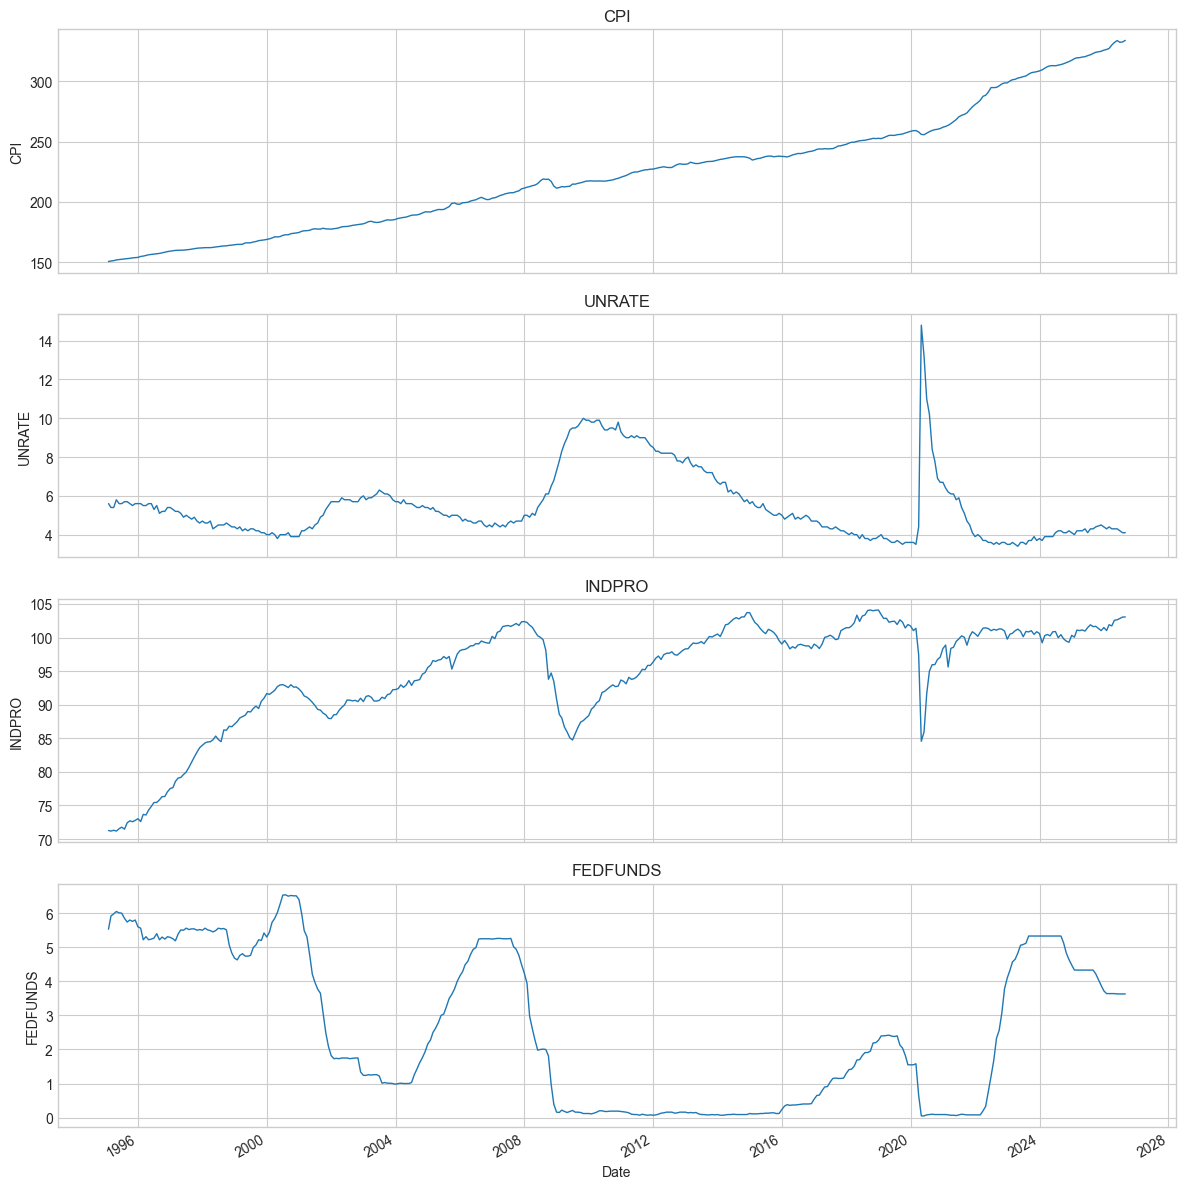

In [4]:
# CELL 3: FIGURE 1 - TIME PLOTS (LEVELS)
n = len(data.columns)
fig, axs = plt.subplots(n, 1, sharex=True, figsize=(12, 3 * n))
for ax, col in zip(np.atleast_1d(axs), data.columns):
    data[col].plot(ax=ax, linewidth=1, xlabel="Date", ylabel=col, title=col)
fig.tight_layout()
plt.show()

In [ ]:
# CELL 4: FIGURE 2 - ADF TEST ON LEVELS (5% level, trend='c', BIC)
def adf_table(df):
    rows = {}
    for c in df.columns:
        a = ADF(df[c].dropna(), trend="c", method="bic")
        rows[c] = {"ADF Test Statistic": a.stat, "5% Critical Value": a.critical_values["5%"],
                   "p-value": a.pvalue, "Stationary": a.stat < a.critical_values["5%"]}
    return pd.DataFrame(rows).T.round(4)

print("--- ADF on LEVELS (Stationary=False -> unit root) ---")
adf_table(data)

In [ ]:
# CELL 5: FIGURES 3 & 4 - TRANSFORM (logdiff or diff) + ADF
def make_stationary(df):
    out = pd.DataFrame(index=df.index)
    for i in INDICATORS:
        a = i["alias"]
        out[a] = np.log(df[a]).diff() * SCALE if i["transform"] == "logdiff" else df[a].diff()
    return out.dropna()

diff_data = make_stationary(data)

if EXCLUDE_COVID:
    covid_rows = diff_data.loc["2020-03":"2021-06"].index
    diff_data = diff_data.drop(covid_rows)
    print(f"Excluded {len(covid_rows)} COVID rows")

fig, axs = plt.subplots(n, 1, sharex=True, figsize=(12, 3 * n))
for ax, col in zip(np.atleast_1d(axs), diff_data.columns):
    diff_data[col].plot(ax=ax, linewidth=1, xlabel="Date", ylabel=f"{col} change", title=f"{col} (stationary form)")
fig.tight_layout()
plt.show()

print("--- ADF on TRANSFORMED data ---")
adf_table(diff_data)

In [ ]:
# CELL 6: GRANGER CAUSALITY (all ordered pairs)
def granger(df, cause, effect, maxlag=4):
    with contextlib.redirect_stdout(io.StringIO()):
        r = grangercausalitytests(df[[effect, cause]], maxlag=maxlag)
    return pd.DataFrame([{
        "Lag": l,
        "F-Stat": round(r[l][0]["ssr_ftest"][0], 4),
        "p-value": round(r[l][0]["ssr_ftest"][1], 4),
        "Significant (p<0.05)": r[l][0]["ssr_ftest"][1] < 0.05} for l in range(1, maxlag + 1)])

for a, b in itertools.permutations(diff_data.columns, 2):
    print(f"\n--- Does {a} Granger-cause {b}? ---")
    print(granger(diff_data, cause=a, effect=b).to_string(index=False))

In [ ]:
# CELL 7: BVAR ENGINE + CHOOSE LAMBDA (replaces lag selection, Fig 5)
def lag_matrix(Y, p):
    T = len(Y)
    X = np.hstack([Y[p - l: T - l] for l in range(1, p + 1)] + [np.ones((T - p, 1))])
    return Y[p:], X

def ar1_sigma(Y):                       # scale of each series (used by the prior)
    s = []
    for j in range(Y.shape[1]):
        y = Y[:, j]
        x = np.column_stack([y[:-1], np.ones(len(y) - 1)])
        b = np.linalg.lstsq(x, y[1:], rcond=None)[0]
        s.append(np.std(y[1:] - x @ b, ddof=2))
    return np.array(s)

def fit_bvar(Y, p, lam, decay=DECAY):
    """Minnesota prior via dummy observations. Prior: coefficients ~ 0, tighter for
    far lags (decay) and controlled by lam. Data are already stationary, so prior mean = 0."""
    n = Y.shape[1]
    y, x = lag_matrix(Y, p)
    sig = ar1_sigma(Y)
    k = n * p + 1
    Yd = np.zeros((n * p + n + 1, n))
    Yd[n * p:n * p + n] = np.diag(sig)
    Xd = np.zeros((n * p + n + 1, k))
    Xd[:n * p, :n * p] = np.kron(np.diag(np.arange(1, p + 1) ** decay), np.diag(sig)) / lam
    Xd[-1, -1] = 1e-5                                   # loose prior on intercept
    Ys, Xs = np.vstack([y, Yd]), np.vstack([x, Xd])
    XtX_inv = np.linalg.inv(Xs.T @ Xs)
    XtX_inv = (XtX_inv + XtX_inv.T) / 2
    B = XtX_inv @ Xs.T @ Ys                             # posterior mean of coefficients
    res = Ys - Xs @ B
    S = res.T @ res
    dof = len(Ys) - k
    return {"B": B, "XtX_inv": XtX_inv, "S": S, "Sigma": S / dof, "nu": dof + n + 1, "p": p, "n": n}

def predict_next(Y, B, p):
    x = np.concatenate([Y[-l] for l in range(1, p + 1)] + [[1.0]])
    return x @ B

def oos_score(Yall, p, lam):
    """Relative RMSE vs 'historical mean' forecast on the last HOLDOUT obs. <1 = beats the mean."""
    H, R = HOLDOUT[FREQ], REFIT_EVERY[FREQ]
    T = len(Yall); start = T - H
    e, e0 = [], []
    for t in range(start, T):
        if (t - start) % R == 0:
            m = fit_bvar(Yall[:t], p, lam)
            mu = Yall[:t].mean(axis=0)
        e.append(Yall[t] - predict_next(Yall[:t], m["B"], p))
        e0.append(Yall[t] - mu)
    return np.sqrt((np.array(e) ** 2).mean(0)) / np.sqrt((np.array(e0) ** 2).mean(0))

Yv = diff_data.values
names = list(diff_data.columns); n = len(names)
p = P_LAGS[FREQ]

rows = {}
for lam in LAMBDA_GRID + [OLS_LAM]:
    rel = oos_score(Yv, p, lam)
    key = lam if lam != OLS_LAM else "OLS (no prior)"
    rows[key] = {**dict(zip(names, rel.round(3))), "AVG": round(rel.mean(), 3)}
print("Relative RMSE vs historical-mean forecast (lower is better, <1 beats the mean):")
print(pd.DataFrame(rows).T)

best_lam = min(LAMBDA_GRID, key=lambda l: rows[l]["AVG"])
print(f"\nBest lambda: {best_lam}")

In [ ]:
# CELL 8: FIGURE 6 - FIT BVAR + POSTERIOR DRAWS
LAMBDA = best_lam                       # or set your own value
bvar = fit_bvar(Yv, p, LAMBDA)
ols  = fit_bvar(Yv, p, OLS_LAM)         # same model without prior, for comparison

def lag1(m):
    return pd.DataFrame(m["B"][:n].T, index=[f"{c} eq" for c in names],
                        columns=[f"L1.{c}" for c in names]).round(3)

print("BVAR lag-1 coefficients (rows = equations):"); print(lag1(bvar))
print("\nOLS VAR lag-1 coefficients:");               print(lag1(ols))
print(f"\nMean |coef|  BVAR: {np.abs(bvar['B'][:-1]).mean():.4f} | OLS: {np.abs(ols['B'][:-1]).mean():.4f}  (shrinkage)")

def posterior_draws(m, n_draws=N_DRAWS):
    Sig = invwishart.rvs(df=m["nu"], scale=m["S"], size=n_draws,
                         random_state=rng).reshape(n_draws, m["n"], m["n"])
    A = np.linalg.cholesky(m["XtX_inv"])
    Bs = np.empty((n_draws,) + m["B"].shape)
    for d in range(n_draws):
        C = np.linalg.cholesky(Sig[d])
        Bs[d] = m["B"] + A @ rng.standard_normal(m["B"].shape) @ C.T
    return Bs, Sig

Bs, Sig = posterior_draws(bvar)

In [ ]:
# CELL 9: DIAGNOSTICS - STABILITY + RESIDUAL AUTOCORRELATION
def companion(B, n, p):
    C = np.zeros((n * p, n * p))
    C[:n] = B[:-1].T
    if p > 1:
        C[n:, :-n] = np.eye(n * (p - 1))
    return C

def max_root(B):
    return np.abs(np.linalg.eigvals(companion(B, n, p))).max()

print(f"Largest root (posterior mean): {max_root(bvar['B']):.4f}  -> stable = {max_root(bvar['B']) < 1}")
print(f"Share of stable posterior draws: {np.mean([max_root(Bs[d]) < 1 for d in range(N_DRAWS)]):.1%}")

y_, x_ = lag_matrix(Yv, p)
resid = y_ - x_ @ bvar["B"]
print(f"\nLjung-Box p-values ({PER_YEAR[FREQ]} lags, p > 0.05 is good):")
for j, c in enumerate(names):
    pv = acorr_ljungbox(resid[:, j], lags=[PER_YEAR[FREQ]], return_df=True)["lb_pvalue"].iloc[0]
    print(f"  {c}: {pv:.4f}")

In [ ]:
# CELL 10: IRF (with bands) + FEVD
H = PER_YEAR[FREQ]

def irf_matrices(B, Sigma):             # orthogonalized (Cholesky) - order = INDICATORS order
    C = companion(B, n, p); P = np.linalg.cholesky(Sigma)
    J = np.hstack([np.eye(n), np.zeros((n, n * (p - 1)))])
    out = np.empty((H + 1, n, n)); Ck = np.eye(n * p)
    for h in range(H + 1):
        out[h] = J @ Ck @ J.T @ P       # out[h, i, j] = response of i to shock j
        Ck = Ck @ C
    return out

D_IRF = min(N_DRAWS, 500)
irfs = np.array([irf_matrices(Bs[d], Sig[d]) for d in range(D_IRF)])
lo, med, hi = np.percentile(irfs, [16, 50, 84], axis=0)

fig, axs = plt.subplots(n, n, figsize=(3.2 * n, 2.6 * n), sharex=True)
for i in range(n):
    for j in range(n):
        ax = axs[i, j]
        ax.plot(med[:, i, j]); ax.axhline(0, color="k", lw=0.5)
        ax.fill_between(range(H + 1), lo[:, i, j], hi[:, i, j], alpha=0.25)
        if i == 0: ax.set_title(f"shock: {names[j]}", fontsize=9)
        if j == 0: ax.set_ylabel(f"resp: {names[i]}", fontsize=9)
fig.suptitle("Orthogonalized IRF (median + 68% band)", y=1.01)
plt.tight_layout(); plt.show()

cum = np.cumsum(irf_matrices(bvar["B"], bvar["Sigma"]) ** 2, axis=0)
fevd = cum / cum.sum(axis=2, keepdims=True)
fig, axs = plt.subplots(1, n, figsize=(4 * n, 3.5), sharey=True)
for i, ax in zip(range(n), np.atleast_1d(axs)):
    ax.stackplot(range(H + 1), fevd[:, i, :].T, labels=names)
    ax.set_title(f"FEVD: {names[i]}", fontsize=10)
np.atleast_1d(axs)[-1].legend(loc="center right", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# CELL 11: FIGURE 7 - FORECAST OF TRANSFORMED SERIES (fan chart)
steps = FORECAST_STEPS[FREQ]

def simulate(Bs, Sig, Y, p, steps):     # each draw: own coefficients + own shocks
    D = len(Bs); paths = np.empty((D, steps, Y.shape[1]))
    for d in range(D):
        h = Y[-p:].copy(); L = np.linalg.cholesky(Sig[d])
        for s in range(steps):
            x = np.concatenate([h[-l] for l in range(1, p + 1)] + [[1.0]])
            yv = x @ Bs[d] + L @ rng.standard_normal(Y.shape[1])
            paths[d, s] = yv; h = np.vstack([h[1:], yv])
    return paths

paths = simulate(Bs, Sig, Yv, p, steps)
idx = pd.date_range(start=data.index[-1] + BAR[FREQ], periods=steps, freq=BAR[FREQ])
q_ch = np.percentile(paths, [5, 16, 50, 84, 95], axis=0)

fig, axs = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)
for j, ax in zip(range(n), np.atleast_1d(axs)):
    ax.plot(diff_data[names[j]].tail(3 * PER_YEAR[FREQ]), label="Historical")
    ax.plot(idx, q_ch[2][:, j], label="BVAR median")
    ax.fill_between(idx, q_ch[1][:, j], q_ch[3][:, j], alpha=0.35, label="68% band")
    ax.fill_between(idx, q_ch[0][:, j], q_ch[4][:, j], alpha=0.15, label="90% band")
    ax.set_ylabel(names[j])
np.atleast_1d(axs)[0].legend(ncol=4)
plt.tight_layout(); plt.show()

In [ ]:
# CELL 12: FIGURE 8 - FORECAST OF LEVELS (each draw rebuilt by its own transform)
levels = np.empty_like(paths)
for j, inst in enumerate(INDICATORS):
    last = data[inst["alias"]].iloc[-1]
    cs = paths[:, :, j].cumsum(axis=1)
    levels[:, :, j] = np.exp(np.log(last) + cs / SCALE) if inst["transform"] == "logdiff" else last + cs

q = np.percentile(levels, [5, 16, 50, 84, 95], axis=0)      # (5, steps, n)
df_forecast = pd.DataFrame(q[2], index=idx, columns=[f"{c}Forecast" for c in names])
print(df_forecast.round(3))

hist = PER_YEAR[FREQ] * 10
for j, col in enumerate(names):
    plt.figure(figsize=(14, 4.5))
    plt.plot(data[col].tail(hist), label=f"Historical {col}")
    plt.plot(idx, q[2][:, j], label="BVAR median")
    plt.fill_between(idx, q[1][:, j], q[3][:, j], alpha=0.35, label="68% band")
    plt.fill_between(idx, q[0][:, j], q[4][:, j], alpha=0.15, label="90% band")
    plt.axvline(idx[0], color="b", alpha=0.5, linestyle="--")
    plt.title(f"BVAR Level Forecast: {col}")
    plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# CELL 13: YoY % FORECAST WITH BANDS
py = PER_YEAR[FREQ]
for j, inst in enumerate(INDICATORS):
    if inst["transform"] == "logdiff":
        a = inst["alias"]
        hist_last = np.repeat(data[a].values[-py:][None], N_DRAWS, axis=0)
        full = np.concatenate([hist_last, levels[:, :, j]], axis=1)
        yoy = (full[:, py:] / full[:, :-py] - 1) * 100
        ql, qm, qh = np.percentile(yoy, [16, 50, 84], axis=0)
        print(f"\n{a} YoY % forecast:")
        print(pd.DataFrame({"median": qm, "low68": ql, "high68": qh}, index=idx).round(2).to_string())

        plt.figure(figsize=(14, 4))
        plt.plot((data[a].pct_change(py) * 100).tail(5 * py), label="Historical YoY %")
        plt.plot(idx, qm, label="BVAR median")
        plt.fill_between(idx, ql, qh, alpha=0.3, label="68% band")
        plt.axvline(idx[0], color="b", alpha=0.5, linestyle="--")
        plt.title(f"{a} YoY %"); plt.legend(); plt.tight_layout(); plt.show()